# Amazon Sales Dataset - 고객 등급별 세부 분석
## RFM 기반 멤버십 등급 분석

---

## 📋 분석 개요

본 분석은 RFM 세그먼테이션을 통해 도출된 등급 중 **매출 기여도가 가장 높은 Platinum과 Gold** 를 대상으로 지출 차이의 원인을 심층 분석하고, Platinum 전환 유도 전략을 제시한다.

| 항목 | 내용 |
|------|------|
| 분석 대상 | Platinum + Gold (충성 고객군) |
| 분석 기간 | 2023-12-29 ~ 2024-12-29 |
| Platinum | 3,629명 (22.02%) |
| Gold | 3,863명 (23.44%) |
| 합계 | 7,492명 (45.46%) |

---

## 📊 분석 배경

매출 기여도 기준으로 **Platinum(26.12%)과 Gold(23.63%)** 의 합산 매출 기여도가 49.75%로 전체 매출의 절반 가까이를 차지하는 핵심 그룹이다. 그러나 1인당 지출은 Platinum(USD 1,320)과 Gold(USD 1,122)로 약 USD 200의 차이가 존재한다. 이 차이의 원인을 파악하여 Gold 고객의 Platinum 전환 전략을 수립한다.

---

## 📊 분석 방향
### 🔮 Platinum + 🥇 Gold (충성 고객군)
**핵심 문제: 왜 Gold는 Platinum보다 덜 쓰는가?**

> 💡 **가설 1**: Platinum 고객은 Gold 대비 높은 총 지출을 보이므로, 카테고리별 평균 객단가 또한 더 높을 것이다.

> 💡 **가설 2**: Platinum 고객은 Gold 대비 구매 빈도 또한 높을 것이다.

In [1]:
import pandas as pd
import numpy as np
from sqlalchemy import create_engine
import plotly.graph_objects as go
from plotly.subplots import make_subplots
from dotenv import load_dotenv
import os

load_dotenv()  # .env 파일 로드

# MySQL 연결
engine = create_engine(
    f"mysql+mysqlconnector://{os.getenv('DB_USER')}:{os.getenv('DB_PASSWORD')}"
    f"@{os.getenv('DB_HOST')}/{os.getenv('DB_NAME')}"
)


In [2]:
# Platinum, Gold등급의 카테고리별 평균 객단가
query="""
SELECT
    o.Category,
    r.Grade,
    AVG(o.TotalAmount) AS AOV
FROM orders_info o
JOIN rfm_result r ON r.CustomerID = o.CustomerID
WHERE r.Grade IN ('Gold', 'Platinum')
	AND o.OrderDate >= DATE_SUB('2024-12-29', INTERVAL 1 YEAR)
	AND o.OrderDate <= '2024-12-29' 
GROUP BY o.Category, r.Grade
ORDER BY r.Grade, AOV;
"""

pg_cat_aov = pd.read_sql(query, engine)

In [3]:
pg_cat_aov

,Category,Grade,AOV
0,Sports & Outdoors,Gold,899.387953
1,Books,Gold,941.281790
2,Toys & Games,Gold,943.926841
3,Home & Kitchen,Gold,947.176263
4,Clothing,Gold,950.446614
5,Electronics,Gold,965.892074
6,Books,Platinum,977.131051
7,Electronics,Platinum,1003.940794
8,Home & Kitchen,Platinum,1007.850128
9,Sports & Outdoors,Platinum,1015.954609


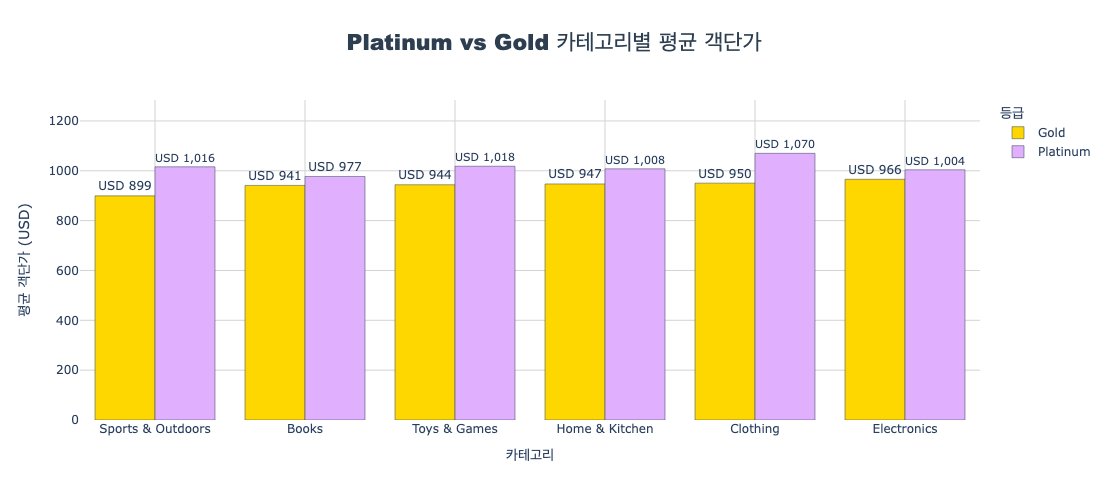

In [4]:
fig = go.Figure()

colors = {'Gold': '#FFD700', 'Platinum': '#E0B0FF'}

for grade in ['Gold', 'Platinum']:
    data = pg_cat_aov[pg_cat_aov['Grade'] == grade]
    fig.add_trace(
        go.Bar(
            x=data['Category'],
            y=data['AOV'],
            name=grade,
            marker_color=colors[grade],
            marker=dict(line=dict(color='#2c3e50', width=0.5)),
            text=data['AOV'].apply(lambda x: f'USD {x:,.0f}'),
            textposition='outside'
        )
    )

fig.update_layout(
    title=dict(
        text='Platinum vs Gold 카테고리별 평균 객단가',
        font=dict(size=22, color='#2c3e50', family='Arial Black'),
        x=0.5,
        xanchor='center'
    ),
    height=500,
    width=1000,
    plot_bgcolor='white',
    barmode='group',
    legend=dict(title='등급')
)

fig.update_xaxes(title_text='카테고리', gridcolor='lightgray')
fig.update_yaxes(
    title_text='평균 객단가 (USD)',
    gridcolor='lightgray',
    range=[0, pg_cat_aov['AOV'].max() * 1.2]
)

fig.show()

### 카테고리별 평균 객단가 비교

**가설 1**: Platinum 고객은 Gold 대비 높은 총 지출을 보이므로, 카테고리별 평균 객단가 또한 더 높을 것이다.

**Platinum(USD 1,320)** 과 **Gold(USD 1,122)** 의 1인당 지출 차이가 카테고리별 객단가 차이에서 비롯되는지 검증한다.

---

분석 결과, **모든 카테고리에서 Platinum의 평균 객단가가 Gold보다 높게** 나타났다.

**→ 가설 검증 결과**:
- 카테고리별 객단가가 Platinum이 Gold보다 높아 **가설이 채택**되었다. 이로써 카테고리별 단가 차이가 총 지출 차이의 한 요인임을 확인했다. 그러나 객단가 차이만으로 지출 격차를 완전히 설명할 수 있는지 확인하기 위해, 추가로 **구매 빈도** 관점에서도 분석을 진행한다.

### 구매 빈도 비교

**가설 2**: Platinum 고객은 Gold 대비 구매 빈도 또한 높을 것이다.

In [5]:
query="""
SELECT 
	o.CustomerID,
    r.Grade,
    COUNT(o.OrderID) AS purchase_count
FROM orders_info o
JOIN rfm_result r ON r.CustomerID = o.CustomerID
WHERE r.Grade IN ('Platinum', 'Gold')
	AND o.OrderDate >= DATE_SUB('2024-12-29', INTERVAL 1 YEAR)
    AND o.OrderDate <= '2024-12-29'
GROUP BY r.Grade, o.CustomerID;
"""

freq_pg = pd.read_sql(query, engine)

In [6]:
freq_pg.head()

,CustomerID,Grade,purchase_count
0,CUST020850,Gold,1
1,CUST007600,Gold,1
2,CUST024904,Platinum,1
3,CUST026727,Gold,1
4,CUST012422,Platinum,1


In [7]:
freq_pg.groupby('Grade')['purchase_count'].describe().round(2)

,count,mean,std,min,25%,50%,75%,max
Grade,,,,,,,,
Gold,3863.0,1.19,0.43,1.0,1.0,1.0,1.0,4.0
Platinum,3629.0,1.30,0.53,1.0,1.0,1.0,2.0,4.0


In [8]:
# 구매 횟수별 고객 분포
freq_dist = freq_pg.groupby(['Grade', 'purchase_count']).size().reset_index(name='Count')

# 전체 고객 수 대비 비율 계산
total = freq_pg.groupby('Grade')['CustomerID'].count()
freq_dist['ratio(%)'] = freq_dist.apply(
    lambda x: round(x['Count'] / total[x['Grade']] * 100, 2), axis=1
)

In [9]:
freq_dist

,Grade,purchase_count,Count,ratio(%)
0,Gold,1,3183,82.40
1,Gold,2,620,16.05
2,Gold,3,58,1.50
3,Gold,4,2,0.05
4,Platinum,1,2659,73.27
5,Platinum,2,861,23.73
6,Platinum,3,96,2.65
7,Platinum,4,13,0.36


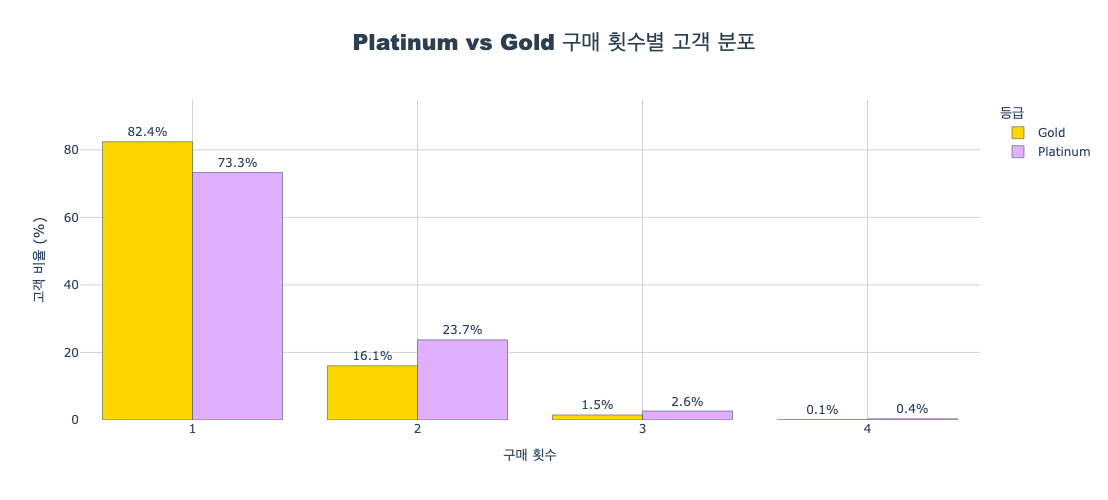

In [10]:
# 시각화
fig = go.Figure()

colors = {'Gold': '#FFD700', 'Platinum': '#E0B0FF'}

for grade in ['Gold', 'Platinum']:
    data = freq_dist[freq_dist['Grade'] == grade]
    fig.add_trace(
        go.Bar(
            x=data['purchase_count'],
            y=data['ratio(%)'],
            name=grade,
            marker_color=colors[grade],
            marker=dict(line=dict(color='#2c3e50', width=0.5)),
            text=data['ratio(%)'].apply(lambda x: f'{x:.1f}%'),
            textposition='outside'
        )
    )

fig.update_layout(
    title=dict(
        text='Platinum vs Gold 구매 횟수별 고객 분포',
        font=dict(size=22, color='#2c3e50', family='Arial Black'),
        x=0.5,
        xanchor='center'
    ),
    height=500,
    width=800,
    plot_bgcolor='white',
    barmode='group',
    legend=dict(title='등급')
)

fig.update_xaxes(
    title_text='구매 횟수',
    tickvals=sorted(freq_dist['purchase_count'].unique()),
    gridcolor='lightgray'
)
fig.update_yaxes(
    title_text='고객 비율 (%)',
    gridcolor='lightgray',
    range=[0, freq_dist['ratio(%)'].max() * 1.15]
)

fig.show()

### 구매 횟수별 고객 분포 분석

분석 결과, Platinum의 평균 구매 횟수(1.30회)가 Gold(1.19회)보다 **약 9% 높게** 나타났다. 특히 1회 구매 고객 비율은 Gold(82.4%)가 Platinum(73.3%)보다 높고, 2회 이상 구매 비율은 Platinum(26.7%)이 Gold(17.6%)보다 약 1.5배 높게 나타났다.

**→ 가설 검증 결과**:
- Platinum이 Gold 대비 구매 빈도가 높은 것으로 확인되어 **가설이 채택**되었다. 이로써 Platinum의 높은 총 지출은 **카테고리별 객단가와 구매 빈도 두 요인이 복합적으로 작용**한 결과임을 확인했다.

---

### 추가 분석 사항
> 📌 **Platinum 구매 사이클 분석 배경**
>
> 구매 빈도 분석에서 Gold의 82.4%가 1회 구매에 그치는 반면 Platinum은 26.7%가 재구매 경험이 있음을 확인했다. Gold 고객의 재구매를 유도하기 위한 리마인드 전략 수립 시 적절한 시점 기준이 필요하다. 이에 재구매 경험이 있는 **Platinum 고객의 구매 사이클을 기준값으로 활용**하여 Gold 고객 대상 리마인드 발송 시점을 설정한다.

In [11]:
query = """
WITH first_purchase AS (
    SELECT 
        CustomerID, 
        MIN(OrderDate) AS 첫_구매일
    FROM orders_info
    WHERE OrderDate >= DATE_SUB('2024-12-29', INTERVAL 1 YEAR)
        AND OrderDate <= '2024-12-29'
    GROUP BY CustomerID
),

second_purchase AS (
    SELECT 
        o.CustomerID, 
        MIN(o.OrderDate) AS 두번째_구매일
    FROM orders_info o
    JOIN first_purchase fp ON o.CustomerID = fp.CustomerID
        AND o.OrderDate > fp.첫_구매일
    WHERE o.OrderDate <= '2024-12-29'
    GROUP BY o.CustomerID
)

SELECT 
    r.Grade,
    DATEDIFF(sp.두번째_구매일, fp.첫_구매일) AS repurchase_cycle
FROM first_purchase fp
JOIN second_purchase sp ON fp.CustomerID = sp.CustomerID
JOIN rfm_result r ON fp.CustomerID = r.CustomerID
WHERE r.Grade = 'Platinum'
"""

df_cycle_pg = pd.read_sql(query, engine)

In [12]:
df_cycle_pg['repurchase_cycle'].describe()

count    967.000000
mean     139.115822
std       82.632885
min        1.000000
25%       68.500000
50%      134.000000
75%      205.000000
max      357.000000
Name: repurchase_cycle, dtype: float64

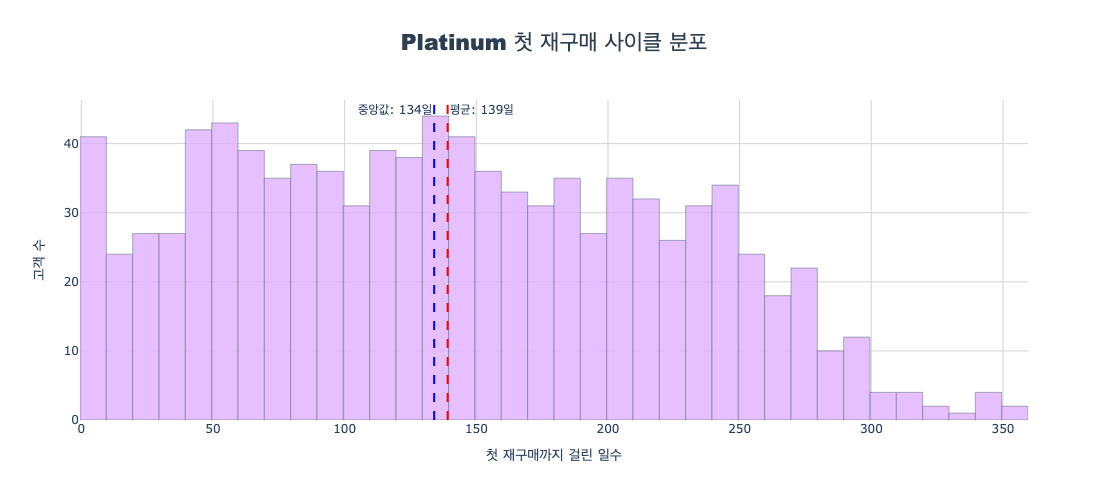

In [13]:
fig = go.Figure(go.Histogram(
    x=df_cycle_pg['repurchase_cycle'],
    marker=dict(
        color='#E0B0FF',
        line=dict(color='#2c3e50', width=0.5)
    ),
    nbinsx=50,
    opacity=0.8,
    showlegend=False
))

mean_val = df_cycle_pg['repurchase_cycle'].mean()
median_val = df_cycle_pg['repurchase_cycle'].median()

fig.add_vline(
    x=mean_val,
    line_dash='dash',
    line_color='red',
    annotation_text=f'평균: {mean_val:.0f}일',
    annotation_position='top right'
)

fig.add_vline(
    x=median_val,
    line_dash='dash',
    line_color='blue',
    annotation_text=f'중앙값: {median_val:.0f}일',
    annotation_position='top left'
)

fig.update_layout(
    title=dict(
        text='Platinum 첫 재구매 사이클 분포',
        font=dict(size=22, color='#2c3e50', family='Arial Black'),
        x=0.5,
        xanchor='center'
    ),
    height=500,
    width=900,
    plot_bgcolor='white'
)

fig.update_xaxes(title_text='첫 재구매까지 걸린 일수', gridcolor='lightgray')
fig.update_yaxes(title_text='고객 수', gridcolor='lightgray')

fig.show()

## **충성 고객 (Platinum + Gold) 솔루션**

### 분석 결과 요약
- 카테고리별 객단가에서 Platinum이 모든 카테고리에서 Gold보다 높게 나타남 (가설 1 채택)
- 구매 빈도도 Platinum(1.30회)이 Gold(1.19회)보다 높게 나타남 (가설 2 채택)
- 즉 두 등급의 총 지출 차이는 **카테고리별 객단가와 구매 빈도 두 요인이 복합적으로 작용**한 결과
- Gold의 82.4%가 1회 구매에 그쳐 **재구매 유도**가 핵심 과제

---

> ✅ **액션 아이템**
> 
> **🔮 Platinum 대상**
> - **1**. **"Diamond까지 USD XXX 남았습니다"** 등급 전환 알림으로 추가 구매 자극
> - **2**. Diamond 전용 혜택(얼리 액세스, 페이백, 전용 고객센터) **미리 체험** 기회 제공
> - **3**. 구매 사이클(평균 132일) 기반 **4~5개월 시점 리마인드 알림** 발송
> >  - 평균 구매 사이클 기반으로 설정하였으며, 향후 고객별 구매 간격 분포(분위수)를 활용한 개인화 CRM 전략으로 확장 가능
> - **4**. 반복 구매 상품 대상 Subscribe & Save 구독 전환 유도
> ---
> **🥇 Gold 대상**
> - **1**. Platinum 구매 사이클(평균 132일) 기반으로 첫 구매 후 **4~5개월 시점**에 리마인드 알림 발송
> >  - Gold 고객은 대부분 1회 구매에 그쳐 개별 구매 주기 산출이 어렵기 때문에, 세분화된 CRM보다는 평균 구매 사이클 기반 리마인드 전략을 우선 적용
> - **2**. 2회 구매 달성 시 즉각적인 보상(쿠폰, 포인트) 제공으로 재구매 동기 부여
> > - 예) 2회 구매 달성 시 즉시 사용 가능 쿠폰 지급
> - **3**. **"Gold → Platinum까지 USD XXX 남았습니다"** 등급 전환 알림으로 추가 구매 자극
> ---
> **🔮🥇 Gold + Platinum 공통**
> - **1**. 첫 구매 카테고리 기반으로 **연관 상품 및 액세서리 알고리즘 추천**으로 자연스러운 추가 구매 유도
> > - 예) Electronics 구매 고객 → 케이블, 충전기, 보호 케이스 등 액세서리 자동 노출
> > - 예) Sports & Outdoors 구매 고객 → 관련 운동 용품, 보충제 등 추천
> - **2**. 첫 구매 카테고리 외 **미구매 카테고리 타겟 추천**으로 구매 빈도 확대
> > - 예) Books 첫 구매 고객 → Sports & Outdoors, Electronics 등 미구매 카테고리 쿠폰 발송
---

> 🧪 **A/B 테스트 제안**
>
> **🔮 Platinum 대상**
> - **1**. 등급 자극 vs 혜택 체험
> > - 가설: 등급 전환 메시지보다 실제 혜택 체험 제공이 재구매를 더 효과적으로 유도할 것이다
> > - A그룹: "Diamond까지 USD XXX 남았습니다" 등급 전환 알림 발송
> > - B그룹: Diamond 혜택(얼리 액세스, 페이백 등) 미리 체험 기회 제공
> > - 주요 지표(Primary KPI): 알림 발송 후 30일 내 재구매율, 전환율(클릭 → 구매)
> > - 보조 지표(Secondary KPI): AOV(평균 주문 금액), ARPU(고객당 평균 매출)
>
> - **2**. 리마인드 타이밍 검증
> > - 가설: 평균 구매 사이클(132일) 이전 조기 리마인드가 재구매 시점을 앞당길 것이다
> > - A그룹: 구매 후 132일(4~5개월) 시점 리마인드 발송
> > - B그룹: 구매 후 60 ~ 90일 시점 조기 리마인드 발송
> > - 주요 지표(Primary KPI): 재구매율, 구매 간격(구매까지 걸린 기간)
> > - 보조 지표(Secondary KPI): AOV(평균 주문 금액), ARPU(고객당 평균 매출)
>
> ---
>
> **🥇 Gold 대상**
> - **1**. 2번째 구매 유도 방식 비교
> > - 가설: 사후 보상보다 사전 쿠폰 제공이 2번째 구매 전환을 더 효과적으로 유도할 것이다
> > - A그룹: 2회 구매 달성 시 보상 제공
> > - B그룹: 2번째 구매 전에 쿠폰 선제 제공
> > - 주요 지표(Primary KPI): 2nd Purchase Conversion Rate(2번째 구매 전환율)
> > - 보조 지표(Secondary KPI): 구매까지 걸린 시간, AOV(평균 주문 금액)
>
> - **2**. 메시지 유형 테스트
> > - 가설: 단순 할인보다 등급 상승 메시지가 재구매 유도에 더 효과적일 것이다
> > - A그룹: 할인 쿠폰 메시지 발송
> > - B그룹: "Gold → Platinum까지 USD XXX 남았습니다" 등급 전환 알림 발송
> > - 주요 지표(Primary KPI): 2nd Purchase Conversion Rate(2번째 구매 전환율)
> > - 보조 지표(Secondary KPI): AOV(평균 주문 금액), ARPU(고객당 평균 매출)
>
> ---
>
> **🔮🥇 Gold + Platinum 공통**
> - **1**. 연관 상품 추천 vs 미구매 카테고리 추천
> > - 가설: 기존 구매와 연관된 상품 추천이 미구매 카테고리 추천보다 전환율이 높을 것이다
> > - A그룹: 연관 상품(크로스셀) 추천
> > - B그룹: 미구매 카테고리 상품 추천
> > - 주요 지표(Primary KPI): 전환율(클릭 → 구매), 재구매율
> > - 보조 지표(Secondary KPI): AOV(평균 주문 금액), ARPU(고객당 평균 매출)
>
> - **2**. 개인화 추천 vs 인기 상품 추천
> > - 가설: 개인화 추천이 인기 상품 추천보다 재구매 전환율이 높을 것이다
> > - A그룹: 인기 상품 기반 추천
> > - B그룹: 개인화 추천 알고리즘 기반 추천
> > - 주요 지표(Primary KPI): 전환율(클릭 → 구매), 재구매율
> > - 보조 지표(Secondary KPI): CTR(클릭률), AOV(평균 주문 금액)
>
> ---
>
> - **실험 단위**: 고객 단위 랜덤 할당 (User-level Randomization)
> - **실험 기간**: Gold 최소 30 ~ 60일, Platinum 최소 1 구매 사이클(4~5개월) 이상
> - **실험 설계 유의사항**: 동일 고객이 복수 실험에 동시에 노출되지 않도록 실험 간 상호 배타적 그룹으로 분리